<a href="https://colab.research.google.com/github/climatom/BioMetConference/blob/main/notebooks/00_test_environment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pre-workshop Colab setup check

This notebook checks that your Google Colab session can run the tools needed for the climate data analysis tutorial.

Please run every cell from top to bottom.

You do **not** need to install anything on your own computer.

## 1. Check where the notebook is running

This should print information about the Python version and machine.

In [1]:
import sys
import platform

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Machine:", platform.machine())

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Machine: x86_64


## 2. Install required packages

This may take a few moments.

The set of packages that we will use for the actual tutorial could vary, but this provides an initial indication of any potential issues to resolbe

In [2]:
!pip -q install \
    herbie-data \
    cfgrib \
    eccodes \
    xarray \
    netCDF4 \
    numpy \
    matplotlib \
    cartopy \
    tqdm \
    heatindex \
    gdown

## 3. Import the main libraries

In [3]:
# Plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Data access
from herbie import Herbie
import gdown
import xarray as xr

# File formats
import cfgrib
import netCDF4
import eccodes

# Utilities
from tqdm import tqdm
import heatindex

# Notebook display
from IPython.display import display, Markdown

# General (already installed)
import numpy as np
import pandas as pd


print("✅ All modules imported successfully.")


✅ All modules imported successfully.


In [4]:
!wget -q -O workshop_functions.py \
https://raw.githubusercontent.com/climatom/BioMetConference/main/src/workshop_functions.py

import workshop_functions as wf

print("✅ workshop_functions imported successfully.")

✅ workshop_functions imported successfully.


## 4. Make a simple plot

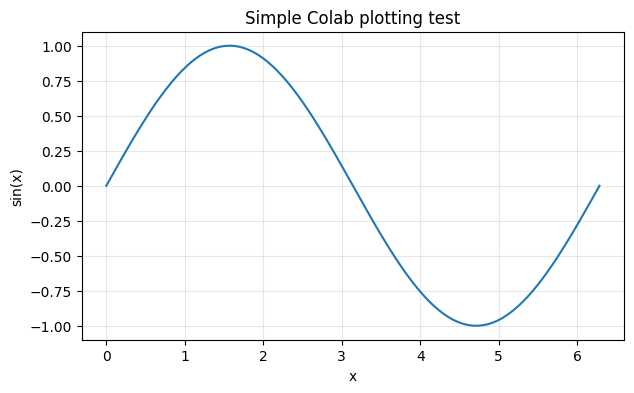

In [5]:
x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

plt.figure(figsize=(7, 4))
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Simple Colab plotting test")
plt.grid(alpha=0.3)
plt.show()

## 5. Open a tiny example dataset with xarray

This uses xarray's built-in tutorial dataset, so no workshop data are needed yet.

In [6]:
ds = xr.tutorial.open_dataset("air_temperature")
ds

<xarray.Dataset> Size: 31MB
Dimensions:  (time: 2920, lat: 25, lon: 53)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Data variables:
    air      (time, lat, lon) float64 31MB ...
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

## 6. Plot a climate-style field

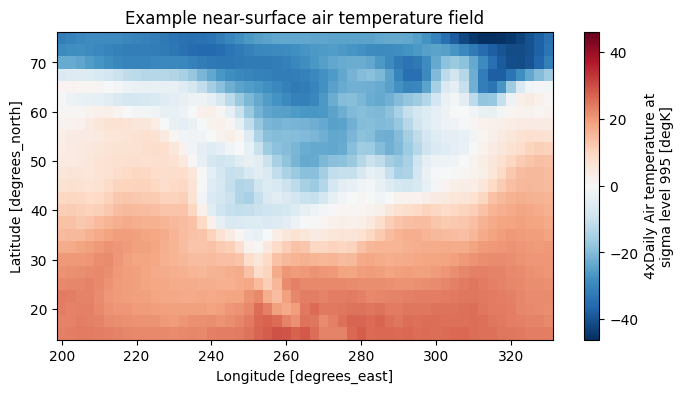

In [7]:
air_c = ds["air"] - 273.15

plt.figure(figsize=(8, 4))
air_c.isel(time=0).plot()
plt.title("Example near-surface air temperature field")
plt.show()

## 7. Optional: quick map test with Cartopy

If this cell fails, do not panic. The rest of the tutorial may still work, but please let Tom know (tom.matthews@kcl.ac.uk).

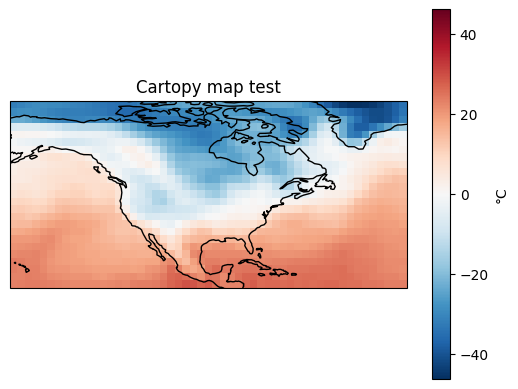

In [8]:

ax = plt.axes(projection=ccrs.PlateCarree())
air_c.isel(time=0).plot(ax=ax, transform=ccrs.PlateCarree(), cbar_kwargs={"label": "°C"})
ax.coastlines()
ax.set_title("Cartopy map test")
plt.show()

## 8. Final check

In [9]:
required = ["np", "pd", "plt", "xr", "wf","Herbie"]
missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(f"Setup check failed. Missing: {missing}")

print("✅ Setup check completed successfully.")
print("You are ready for the tutorial.")

✅ Setup check completed successfully.
You are ready for the tutorial.
